## Time Series Forecasting Fundamentals with TensorFlow

#### Let's predict the price of Bitcoin based on the historical price of Bitcoin.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime as dt
import os
warnings.filterwarnings("ignore")
import tensorflow as tf
print(tf.__version__)

2.18.0


## Get the data...

In [36]:
# !mkdir ~/.kaggle
# !cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download mczielinski/bitcoin-historical-data
!unzip bitcoin-historical-data

Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data
License(s): CC-BY-SA-4.0
bitcoin-historical-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  bitcoin-historical-data.zip
replace btcusd_1-min_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [37]:
df = pd.read_csv("/content/btcusd_1-min_data.csv")
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6779281 entries, 0 to 6779280
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 310.3 MB


In [39]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Date'] = df['Timestamp'].dt.date
df['Time'] = df['Timestamp'].dt.time
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date,Time
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:01:00
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:02:00
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:03:00
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:04:00
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:05:00


In [40]:
df = df.drop(['Timestamp'], axis=1)
df.head()

,Open,High,Low,Close,Volume,Date,Time
0,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:01:00
1,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:02:00
2,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:03:00
3,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:04:00
4,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:05:00


In [41]:
df = df.groupby('Date')['Close'].mean().reset_index()
df.head()

,Date,Close
0,2012-01-01,4.645697
1,2012-01-02,4.975000
2,2012-01-03,5.085500
3,2012-01-04,5.170396
4,2012-01-05,5.954361


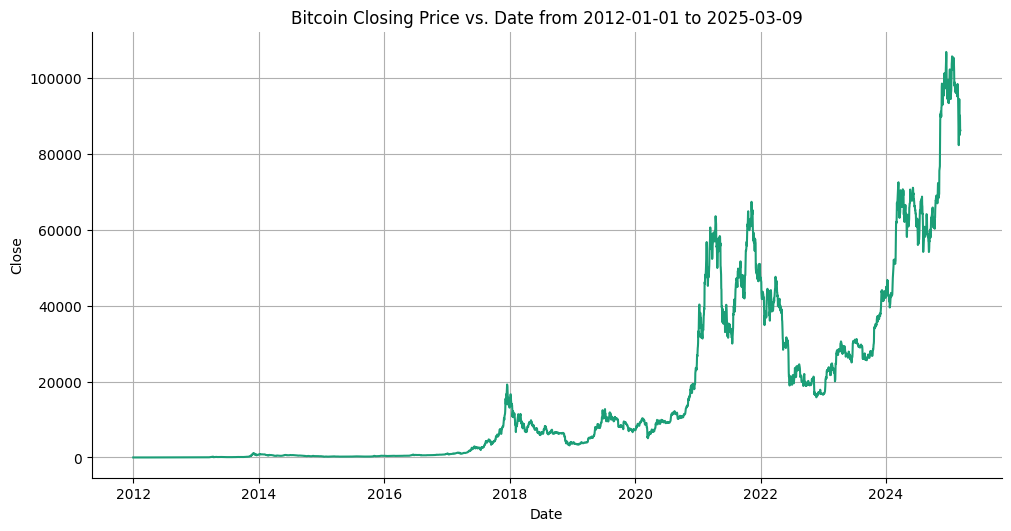

In [42]:
# @title Date vs Close

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Close']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])
  plt.title(f"Bitcoin Closing Price vs. Date from {xs.min()} to {xs.max()}")
  plt.grid(True)
  return plt

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Close')

#### Convert dataset columns to Numpy arrays.

In [48]:
timesteps = df['Date'].to_numpy()
prices = df['Close'].to_numpy()
timesteps,prices

(array([datetime.date(2012, 1, 1), datetime.date(2012, 1, 2),
        datetime.date(2012, 1, 3), ..., datetime.date(2025, 3, 7),
        datetime.date(2025, 3, 8), datetime.date(2025, 3, 9)], dtype=object),
 array([4.64569726e+00, 4.97500000e+00, 5.08550000e+00, ...,
        8.98730000e+04, 8.61657968e+04, 8.61820000e+04]))

#### Create train and test splits

In [51]:
split_size = int(np.size(timesteps) * 0.8)
timesteps_train, timesteps_test = timesteps[:split_size], timesteps[split_size:]
prices_train, prices_test = prices[:split_size], prices[split_size:]

#### Plot train and test datasets.

Text(0, 0.5, 'Close')

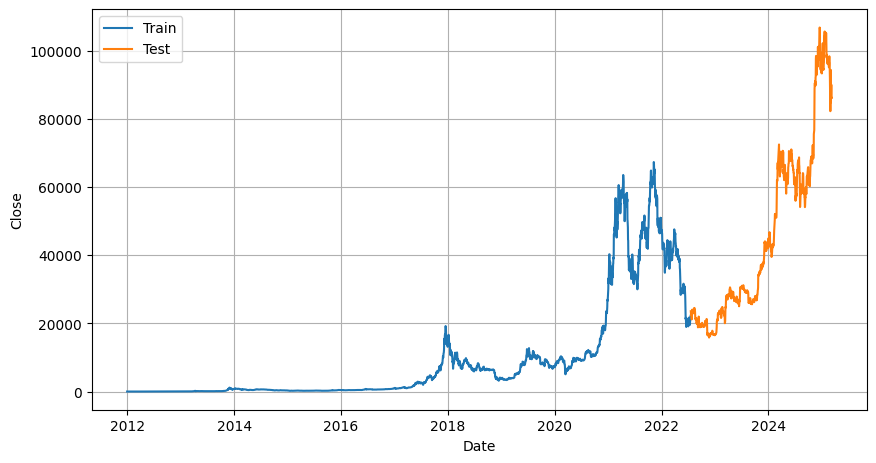

In [54]:
plt.figure(figsize=(10, 5.2))
plt.plot(timesteps_train, prices_train, label='Train')
plt.plot(timesteps_test, prices_test, label='Test')
plt.legend()
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Close')